## LinearRegression Baseline

In [35]:
import pandas as pd

In [2]:
folder_path = '/Users/gtw/Desktop/新能源/负荷/archive-2/PJME_hourly.csv'

In [3]:
df = pd.read_csv(folder_path, parse_dates = ['Datetime'], index_col =[0]) #把datetime转成python能识别的时间对象
df.head()
# Datetime现在变成了index，因为在下面一行，可以根据这个判断

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [4]:
df.dtypes #Datetime成功转成了时间对象, MW意思是兆瓦

PJME_MW    float64
dtype: object

In [7]:
import sys
!{sys.executable} -m pip install holidays

  Using cached holidays-0.95-py3-none-any.whl.metadata (52 kB)
Using cached holidays-0.95-py3-none-any.whl (1.5 MB)


In [8]:
import holidays

In [49]:
#Feature Extraction 
#1. 提取时间特征：进一步处理数据：年月，星期，小时
#df['Year'] = df.index.year，为了和xgb对齐所以删掉
#加上holidays

df = df.sort_index()

us_holidays = holidays.US()

df['is_holidays'] = df.index.date #holidays库认的是date类型
df['is_holidays'] = df['is_holidays'].apply(lambda x: 1 if x in us_holidays else 0)

df['Month'] = df.index.month
df['Week'] = df.index.dayofweek
df['Hour'] = df.index.hour

#Lag Features
#2. 提取滞后特征：滞后24小时, 和一周前同一时刻
df['Lags_24hrs'] = df['PJME_MW'].shift(24)
df['Lags_168hrs'] = df['PJME_MW'].shift(168)

#Scikit-learn 不认na，防止报错所以直接删掉
#3. drop
df = df.dropna()

In [51]:
df.tail(10) #check
#from datetime import date
#print(date(2015, 1, 1) in us_holidays)

,PJME_MW,is_holidays,Month,Week,Hour,Lags_24hrs,Lags_168hrs
Datetime,,,,,,,
2018-08-02 15:00:00,47154.0,0,8,3,15,46430.0,45954.0
2018-08-02 16:00:00,46989.0,0,8,3,16,47867.0,47369.0
2018-08-02 17:00:00,46816.0,0,8,3,17,48855.0,48525.0
2018-08-02 18:00:00,46760.0,0,8,3,18,49308.0,49029.0
2018-08-02 19:00:00,45641.0,0,8,3,19,48428.0,48261.0
2018-08-02 20:00:00,44057.0,0,8,3,20,46912.0,46337.0
2018-08-02 21:00:00,43256.0,0,8,3,21,45985.0,44542.0
2018-08-02 22:00:00,41552.0,0,8,3,22,44094.0,42638.0
2018-08-02 23:00:00,38500.0,0,8,3,23,40666.0,39276.0


In [52]:
#Split Data
#按照时间做切分，数据从2002-2018，决定2015作为分界点
train = df.loc[df.index < '2015-01-01']
test = df.loc[df.index >= '2015-01-01']

#指定特征和目标
Features = ['is_holidays', 'Month', 'Week', 'Hour', 'Lags_24hrs','Lags_168hrs']
Target = ['PJME_MW']

#拆解X和y，完整测试集和训练集的结构
X_train = train[Features]
y_train = train[Target]

X_test = test[Features]
y_test = test[Target]

#check
print(f'训练集大小:{X_train.shape}, 测试集大小:{X_test.shape}')

训练集大小:(113422, 6), 测试集大小:(31440, 6)


In [53]:
#Training
!pip install scikit-learn

In [54]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
#Testing
test['prediction'] = model.predict(X_test)
y_pred = test['prediction']

In [56]:
#RMSE
score = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'测试集的误差评分：{score:0.2f}' )

测试集的误差评分：2624.90


In [57]:
#从 2934 降到 2802，线性回归光靠加特征就降了 130 MW
#现在加一行MAPE
#保证对齐索引能计算，用numpy

mape = np.mean(np.abs(y_test.values - y_pred.values) / y_test.values) * 100
print(f'RMSE: {score: 0.2f}')
print(f'MAPE: {mape: 0.2f}%') 

#业界好的负荷预测大概 3-5%，线性回归只能做到这些，接下来用xgb

RMSE:  2624.90
MAPE:  22.36%


In [58]:
print(type(mape), mape)

<class 'numpy.float64'> 22.36496587036486


## XGBoost

In [59]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators = 1000,
    learing_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xbg_model.predict(X_test)   #是 XGBoost 直接输出的，形状是 (31440,)，一维的

/opt/anaconda3/envs/environment_BU520750/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "learing_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [60]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mape = np.mean(np.abs(y_test.values.flatten() - y_pred_xgb) / y_test.values.flatten()) * 100 #flatten()把二维压成一维

print(f'XGBoost_RMSE: {xgb_rmse:.2f}')
print(f'XGBoost_MAPE: {xgb_mape:.2f}%')

XGBoost_RMSE: 3176.23
XGBoost_MAPE: 7.57%


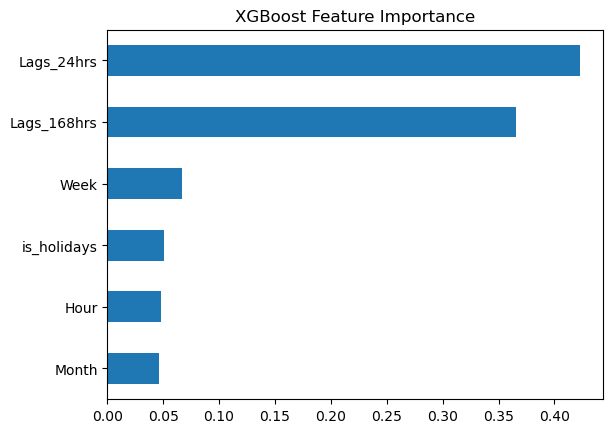

Month          0.046113
Hour           0.048375
is_holidays    0.050460
Week           0.066907
Lags_168hrs    0.365494
Lags_24hrs     0.422652
dtype: float32


In [61]:
#MAPE显著下降，看看特征重要性
#简单看看分裂次数
import matplotlib.pyplot as plt

importance = pd.Series(xgb_model.feature_importances_, index = Features)
importance = importance.sort_values(ascending = True)

importance.plot(kind = 'barh')
plt.title('XGBoost Feature Importance')
plt.show()
print(importance)
                

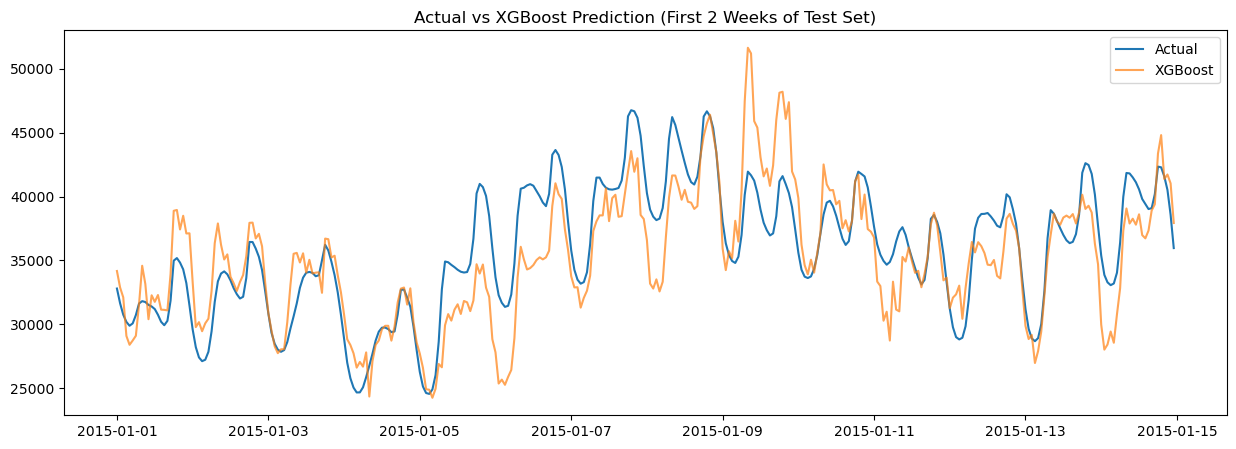

In [62]:
#现在对比真实数据，直观看看预测和真实数据差在哪里

#取测试集前两周看细节
plot_df = test.iloc[:24*14].copy() #按位置取行，取到第336行
plot_df['xgb_pred'] = y_pred_xgb[:24*14]

plt.figure(figsize = (15,5))
plt.plot(plot_df.index, plot_df['PJME_MW'], label = 'Actual')
plt.plot(plot_df.index, plot_df['xgb_pred'], label = 'XGBoost', alpha = 0.7) #线的透明度，方便看重叠
plt.title('Actual vs XGBoost Prediction (First 2 Weeks of Test Set)')
plt.legend()
plt.show()



整体：橙色基本跟着蓝色走，周期感抓住了，说明模型学到了日内和周内的规律。\
1月1日（最左边）：橙色明显高于蓝色，模型高估了。这是元旦，负荷比平时低，但模型没预测到这个下降幅度。is_holiday 特征加了，但还不够——它只告诉模型"今天是节假日"，没告诉模型节假日的负荷曲线形状跟平时完全不同。\
1月9日附近：橙色出现一个很高的尖峰，实际值没那么高，模型明显过冲了。这种尖峰通常是极端天气导致的——没有气象特征，模型只能靠 lag 猜，猜错了。这就是为什么气象数据是下一步要加的东西。\
整体偏移：前半段橙色偏高，后半段两条线贴得比较紧。这说明模型在1月初系统性高估，可能跟年初的特殊消费模式有关。
#### 一句话总结：模型的周期模式学得不错，主要误差来自两个地方：节假日特殊曲线没学好、极端天气没有特征支撑。这两个正好是后续改进的方向。


In [63]:
#check
print(test.shape)
print(test.index[:5]) #取前五行看看
print(len(y_pred_xgb))

(31440, 8)
DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)
31440


In [48]:
print(test.index.is_monotonic_increasing)  # 是否按时间正序排列
print(df.index.is_monotonic_increasing)    # 原始数据也查一下

#数据不是正序排列，在开头sort一下：df = df.sort_index()

False
False


In [70]:
#汇总表

summary = pd.DataFrame(
    {
        'Model': ['LinearRegression', 'XGBoost'],
        'RMSE': [round(2624.90,2), round(xgb_rmse,2)],
        'MAPE': [round(22.36,2), round(xgb_mape,2)]
    }
)

print(summary)

              Model     RMSE   MAPE
0  LinearRegression  2624.90  22.36
1           XGBoost  3176.23   7.57
